In [236]:
import pandas as pd
import numpy as np
import os
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
import scipy as sp
import holidays
from collections import deque
from lightgbm import LGBMRegressor
import joblib

In [171]:
path = "../dataset/pecan-street-electricity-data"

files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".csv")]

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49443400 entries, 0 to 49443399
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   localminute  object 
 1   dataid       int64  
 2   use          float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ GB


In [173]:
df.describe()

,dataid,use
count,4.944340e+07,4.944340e+07
mean,4.308854e+03,9.588876e-01
std,2.911907e+03,1.347736e+00
min,2.600000e+01,-3.194300e+01
25%,1.801000e+03,3.040000e-01
50%,3.719000e+03,5.470000e-01
75%,6.941000e+03,1.004000e+00
max,9.983000e+03,3.194300e+01


In [174]:
df.head()

,localminute,dataid,use
0,2016-01-01 00:00:00-06,8046,0.887
1,2016-01-01 00:00:00-06,9983,1.181
2,2016-01-01 00:00:00-06,8059,0.130
3,2016-01-01 00:00:00-06,9555,1.299
4,2016-01-01 00:00:00-06,8079,2.719


In [175]:
# df_without_timestamp = df.drop(columns=["localminute"])
# scatter_matrix(df_without_timestamp, figsize=(7,7))
# pyplot.show()   

In [176]:
# pyplot.hist(df["use"], bins='auto')
# pyplot.title('Histograma')
# pyplot.ylabel('Frequencia')
# pyplot.xlabel("Uso")
# pyplot.show()

In [177]:
amostra = df.sample(n=1000, random_state=42)

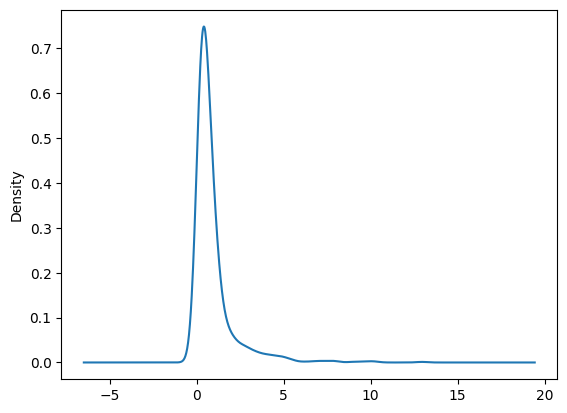

In [178]:
amostra['use'].plot(kind='kde')
# amostra.plot.scatter(x='use', y='dataid', colormap='viridis')
pyplot.show()


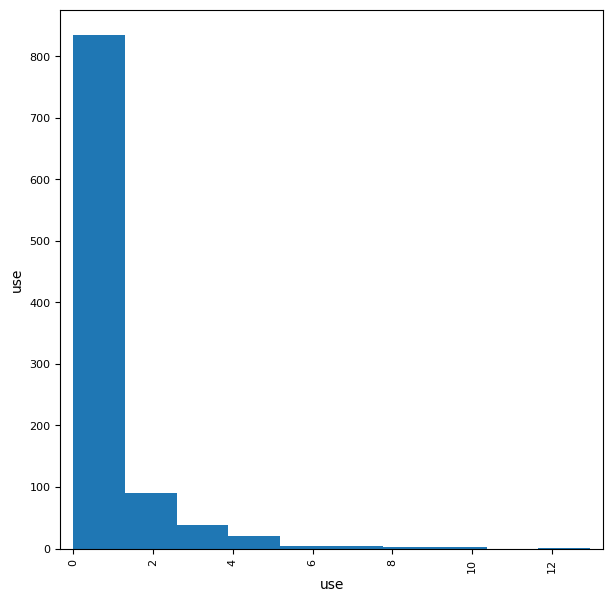

In [179]:
scatter_matrix(amostra.drop(columns=["localminute", "dataid"]), figsize=(7,7))
pyplot.show()

## Agrupando por data

In [180]:
df_aggregated = df.copy()
# df_aggregated = df.sample(100000)
# df_aggregated = df[0:5000000]

### Garante que o timestamp é no formato datetime e define o index

In [181]:
aggregate_freq = "1D"

In [182]:
df_aggregated = (
    df_aggregated
    .assign(localminute=pd.to_datetime(df_aggregated['localminute'], utc=True))
    .groupby([
        'dataid',
        pd.Grouper(key='localminute', freq=aggregate_freq)
    ])
    .mean()
    .dropna()
)

In [183]:
df_aggregated.head()

use
dataid localminute                        
26     2016-01-01 00:00:00+00:00  0.405006
       2016-01-02 00:00:00+00:00  0.423434
       2016-01-03 00:00:00+00:00  0.419911
       2016-01-04 00:00:00+00:00  0.507147
       2016-01-05 00:00:00+00:00  0.409947

In [184]:
df_aggregated.describe()

,use
count,34616.000000
mean,0.960947
std,0.782520
min,-1.171868
25%,0.506981
50%,0.791052
75%,1.179031
max,14.666128


In [185]:
df_aggregated.loc[8046]['use'].mean()

np.float64(1.053686842053346)

In [186]:
df_aggregated.index

MultiIndex([(  26, '2016-01-01 00:00:00+00:00'),
            (  26, '2016-01-02 00:00:00+00:00'),
            (  26, '2016-01-03 00:00:00+00:00'),
            (  26, '2016-01-04 00:00:00+00:00'),
            (  26, '2016-01-05 00:00:00+00:00'),
            (  26, '2016-01-06 00:00:00+00:00'),
            (  26, '2016-01-07 00:00:00+00:00'),
            (  26, '2016-01-08 00:00:00+00:00'),
            (  26, '2016-01-09 00:00:00+00:00'),
            (  26, '2016-01-10 00:00:00+00:00'),
            ...
            (9983, '2016-02-24 00:00:00+00:00'),
            (9983, '2016-02-25 00:00:00+00:00'),
            (9983, '2016-02-26 00:00:00+00:00'),
            (9983, '2016-02-27 00:00:00+00:00'),
            (9983, '2016-02-28 00:00:00+00:00'),
            (9983, '2016-02-29 00:00:00+00:00'),
            (9983, '2016-03-01 00:00:00+00:00'),
            (9983, '2016-03-02 00:00:00+00:00'),
            (9983, '2016-03-03 00:00:00+00:00'),
            (9983, '2016-03-04 00:00:00+00:00')],
   

In [187]:
# df_aggregated['use_norm'] = (
#     df_aggregated['use'] /
#     df_aggregated.groupby(level=0)['use'].transform('mean')
# )

In [188]:
df_aggregated.head(18)

use
dataid localminute                        
26     2016-01-01 00:00:00+00:00  0.405006
       2016-01-02 00:00:00+00:00  0.423434
       2016-01-03 00:00:00+00:00  0.419911
       2016-01-04 00:00:00+00:00  0.507147
       2016-01-05 00:00:00+00:00  0.409947
       2016-01-06 00:00:00+00:00  0.530564
       2016-01-07 00:00:00+00:00  0.827616
       2016-01-08 00:00:00+00:00  0.834849
       2016-01-09 00:00:00+00:00  0.948644
       2016-01-10 00:00:00+00:00  1.066644
       2016-01-11 00:00:00+00:00  0.971763
       2016-01-12 00:00:00+00:00  0.898635
       2016-01-13 00:00:00+00:00  0.597079
       2016-01-14 00:00:00+00:00  0.619945
       2016-01-15 00:00:00+00:00  0.747542
       2016-01-16 00:00:00+00:00  1.353044
       2016-01-17 00:00:00+00:00  1.160401
       2016-01-18 00:00:00+00:00  1.068228

In [189]:
us_holidays = holidays.US()

In [190]:
data_index = 8046

In [191]:
df_aggregated.loc[data_index]

,use
localminute,
2016-01-01 00:00:00+00:00,2.032883
2016-01-02 00:00:00+00:00,1.020242
2016-01-03 00:00:00+00:00,2.062378
2016-01-04 00:00:00+00:00,1.480921
2016-01-05 00:00:00+00:00,1.227542
...,...
2016-02-29 00:00:00+00:00,0.854762
2016-03-01 00:00:00+00:00,0.712694
2016-03-02 00:00:00+00:00,0.812770


In [192]:
df_aggregated.loc[data_index].iloc[2].name in us_holidays

False

In [193]:
us_holidays.get(df_aggregated.loc[data_index].iloc[2].name)

In [194]:
features = [
    "today",
    "lag_1",
    "lag_2",
    "lag_3",

    "lag_7",
    "lag_14",
    "lag_30",

    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7",

    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday",

    "date"

    # "days_since_start",
    # "valid_lags"
]
newdf = pd.DataFrame(columns=features)

In [195]:
df_aggregated.loc[data_index].iloc[4]

use    1.227542
Name: 2016-01-05 00:00:00+00:00, dtype: float64

In [196]:
for dataid, grupo in df_aggregated.groupby(level='dataid'):

    lags = np.full(6, np.nan)
    rolling_mean_7 = np.nan
    rolling_mean_30 = np.nan
    rolling_std_7 = np.nan
    days_since_start = 0
    valid_tags = 1
    last_30_values = deque(([np.nan] * 30), maxlen=30)
    Y = None

    day_of_week = None
    month = None
    is_weekend = None

    # Pega o primeiro elemento e o remove do grupo
    first = grupo.iloc[0]
    grupo = grupo.iloc[1:]
    print(grupo.iloc[0])

    last_30_values.append(first.use)
    lags[0] = first.use # Dia anterior

    for (did, localminute), row in grupo.iterrows():
        lags[1] = last_30_values[28] # Dia -2
        lags[2] = last_30_values[27] # Dia -3
        lags[3] = last_30_values[26] # Dia -7
        lags[4] = last_30_values[23] # Dia -14
        lags[5] = last_30_values[0] # Dia -30

        rolling_mean_7 = np.mean(list(last_30_values)[-7:])
        rolling_mean_30 = np.mean(last_30_values)
        rolling_std_7 = np.std(list(last_30_values)[-7:])

        days_since_start += 1

        valid_tags = np.sum(~np.isnan(lags))

        day_of_week = localminute.dayofweek
        month = localminute.month
        is_weekend = day_of_week >= 5
        is_holiday = localminute in us_holidays


        newdf.loc[len(newdf)] = {
            "today": row['use'],
            "lag_1": lags[0],
            "lag_2": lags[1],
            "lag_3": lags[2],
            "lag_7": lags[3],
            "lag_14": lags[4],
            "lag_30": lags[5],
            "rolling_mean_7": rolling_mean_7,
            "rolling_mean_30": rolling_mean_30,
            "rolling_std_7": rolling_std_7,
            "day_of_week": day_of_week,
            "month": month,
            "is_weekend": is_weekend,
            "date": localminute.to_pydatetime(),
            "is_holiday": is_holiday
        }

        last_30_values.append(row['use'])
        Y = row['use']
        print(lags)
        lags[0] = row['use']

use    0.423434
Name: (26, 2016-01-02 00:00:00+00:00), dtype: float64
[0.40500556        nan        nan        nan        nan        nan]
[0.42343403 0.40500556        nan        nan        nan        nan]
[0.41991111 0.42343403 0.40500556        nan        nan        nan]
[0.50714653 0.41991111 0.42343403 0.40500556        nan        nan]
[0.40994722 0.50714653 0.41991111 0.42343403        nan        nan]
[0.53056389 0.40994722 0.50714653 0.41991111        nan        nan]
[0.82761597 0.53056389 0.40994722 0.50714653 0.40500556        nan]
[0.83484931 0.82761597 0.53056389 0.40994722 0.42343403        nan]
[0.94864375 0.83484931 0.82761597 0.53056389 0.41991111        nan]
[1.06664375 0.94864375 0.83484931 0.82761597 0.50714653        nan]
[0.97176319 1.06664375 0.94864375 0.83484931 0.40994722        nan]
[0.89863542 0.97176319 1.06664375 0.94864375 0.53056389        nan]
[0.59707917 0.89863542 0.97176319 1.06664375 0.82761597        nan]
[0.61994514 0.59707917 0.89863542 0.97176319 0

In [197]:
newdf.head(5)

,today,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,is_weekend,is_holiday,date
0,0.423434,0.405006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,True,False,2016-01-02 00:00:00+00:00
1,0.419911,0.423434,0.405006,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,1,True,False,2016-01-03 00:00:00+00:00
2,0.507147,0.419911,0.423434,0.405006,NaN,NaN,NaN,NaN,NaN,NaN,0,1,False,False,2016-01-04 00:00:00+00:00
3,0.409947,0.507147,0.419911,0.423434,0.405006,NaN,NaN,NaN,NaN,NaN,1,1,False,False,2016-01-05 00:00:00+00:00
4,0.530564,0.409947,0.507147,0.419911,0.423434,NaN,NaN,NaN,NaN,NaN,2,1,False,False,2016-01-06 00:00:00+00:00


In [198]:
newdf = newdf.dropna()

In [199]:
newdf = newdf.sort_values(by="date")

In [223]:
train = newdf[
    newdf["date"] < "2016-03-15"
]

val = newdf[
    (newdf["date"] >= "2016-03-15") &
    (newdf["date"] < "2016-04-10")
]

test = newdf[
    newdf["date"] >= "2016-04-10"
]

In [224]:
train.shape, val.shape, test.shape

((13899, 15), (6252, 15), (4137, 15))

In [ ]:
X_train = train.drop(columns=["today", "date"])
y_train = train["today"]

X_val = val.drop(columns=["today", "date"])
y_val = val["today"]

X_test = test.drop(columns=["today", "date"])
y_test = test["today"]

In [226]:
X_train.head()

,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,is_weekend,is_holiday
29,0.913772,0.711756,0.747669,0.725338,0.836856,0.405006,0.758241,0.767551,0.084566,6,1,True,False
25477,0.707481,0.711531,0.806815,0.955480,0.364242,0.783939,0.731296,0.788687,0.252913,6,1,True,False
25385,0.771963,0.604846,0.562613,0.645124,0.533293,0.602088,0.586536,0.624192,0.092919,6,1,True,False
25293,3.575839,4.160240,7.119692,3.331249,3.799172,4.658280,4.320708,4.636323,1.196451,6,1,True,False
25201,0.694683,0.755433,0.786869,0.691215,0.463688,0.726747,0.642189,0.668938,0.115325,6,1,True,False


In [227]:
y_train.head()

29       0.768937
25477    0.388588
25385    0.746338
25293    4.037339
25201    0.460610
Name: today, dtype: float64

In [228]:
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000232 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2310
[LightGBM] [Info] Number of data points in the train set: 13899, number of used features: 13
[LightGBM] [Info] Start training from score 0.908780


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=1000,
              random_state=42, subsample=0.8)

In [229]:
preds = model.predict(X_test)

In [230]:
print(preds)

[0.69258699 0.84006231 1.05022585 ... 0.39960677 1.99096976 0.72441867]


In [231]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

print(rmse)

0.37977217338614816


In [232]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    preds
)

print(mae)

0.2275693836288714


In [233]:
from sklearn.metrics import mean_absolute_percentage_error

mask = y_test > 0.1

mape = mean_absolute_percentage_error(
    y_test[mask],
    preds[mask]
)
mape

0.21803754956547863

In [221]:
newdf.tail()

,today,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,is_weekend,is_holiday,date
20408,3.445865,2.551343,1.626949,2.205928,2.106859,2.034867,1.333529,2.063969,1.612372,0.344855,5,4,True,False,2016-04-30 00:00:00+00:00
16668,2.882705,1.805845,1.640310,1.458067,2.317579,0.966558,1.355110,1.521397,0.948276,0.451335,5,4,True,False,2016-04-30 00:00:00+00:00
3328,0.363957,0.368466,0.654401,0.396502,0.542892,0.393268,0.543710,0.447608,0.433566,0.100793,5,4,True,False,2016-04-30 00:00:00+00:00
18968,1.394010,1.836902,2.244981,1.656022,1.533962,1.292062,2.042680,1.685406,1.723681,0.273953,5,4,True,False,2016-04-30 00:00:00+00:00
21608,0.761070,0.718133,0.745336,0.734660,0.458027,0.466501,0.941463,0.618687,0.690015,0.122719,5,4,True,False,2016-04-30 00:00:00+00:00


In [237]:
joblib.dump(model, "model.pkl")

['model.pkl']